In [2]:
import os
import re
import pickle
import pandas as pd
import seaborn as sns

logs_dir = "logs"
output_dir = "out"

def get_runtime(run_name):

    out_file = os.path.join(output_dir, f"{run_name}.out")

    if not os.path.exists(out_file):

        return None

    with open(out_file) as f:

        text = f.read()

    m = re.search(r"Time:\s*(.*?)\n", text)

    if m:

        runtime = m.group(1)

        return runtime

    return None

def get_memory(run_name):

    log_file = os.path.join(logs_dir, f"{run_name}.log")

    if not os.path.exists(log_file):

        return None

    with open(log_file) as f:

        text = f.read()

    m = re.search(

    r"Memory\s*\(MB\)\s*:\s*([\d\.]+)",text)

    if m:

        memory = float(m.group(1))

        return memory

    return None



In [9]:
rows = []

for file in os.listdir("./pkl"):
    if not file.endswith(".pkl"):

        continue

    with open(f"./pkl/{file}", "rb") as f:

        graph, cols = pickle.load(f)

    matrix = graph.graph

    directed = 0

    circle_arrow = 0

    bidirected = 0

    for i in range(len(matrix)):

        for j in range(i + 1, len(matrix)):

            a = matrix[i, j]

            b = matrix[j, i]


            if (a,b) == (-1,1) or (a,b) == (1,-1):

                directed += 1

            elif (a,b) == (2,1) or (a,b) == (1,2):

                circle_arrow += 1

            elif (a,b) == (1,1):

                bidirected += 1
    run_name = file.replace(".pkl", "")

    runtime = get_runtime(run_name) 

    memory = get_memory(run_name)   

    rows.append({

        "run": run_name,

        "algorithm": "FCI" if file.startswith("FCI") else "PC",

        "alpha":

            0.01 if "_a01_" in file else

            0.05 if "_a05_" in file else

            0.10,
        "sample_size":5000 if "5k" in file else 10000,

        "directed_edges": directed,

        "circle_arrow_edges": circle_arrow,

        "bidirected_edges": bidirected,

        "total_edges": directed + circle_arrow + bidirected,

        "nodes": len(cols),

        "runtime": runtime,
        
        "memory": memory

    })

df = pd.DataFrame(rows)

df["runtime_hours"] = df["runtime"].apply(lambda x: float(x.split()[0][:-1]) / 3600 if x else None)
df.sort_values(["runtime_hours"])
    

,run,algorithm,alpha,sample_size,directed_edges,circle_arrow_edges,bidirected_edges,total_edges,nodes,runtime,memory,runtime_hours
4,PC_fisherz_simple_a01_10k,PC,0.01,10000,107,0,0,107,25,39.4s (0.01hrs),186.0,0.010944
22,PC_fisherz_simple_a05_10k,PC,0.05,10000,122,0,0,122,25,96.1s (0.03hrs),261.0,0.026694
0,PC_fisherz_simple_a10_10k,PC,0.10,10000,129,0,0,129,25,170.8s (0.05hrs),315.0,0.047444
12,PC_fisherz_simple_a01_full,PC,0.01,10000,135,0,0,135,25,253.3s (0.07hrs),428.0,0.070361
15,PC_fisherz_simple_a05_full,PC,0.05,10000,140,0,0,140,25,267.3s (0.07hrs),612.0,0.074250
2,PC_fisherz_simple_a10_full,PC,0.10,10000,144,0,0,144,25,380.9s (0.11hrs),608.0,0.105806
5,FCI_fisherz_simple_a01_5k_d-1,FCI,0.01,5000,54,6,18,78,25,753.2s (0.21hrs),842.0,0.209222
16,FCI_fisherz_simple_a01_5k_d4,FCI,0.01,5000,52,8,18,78,25,1138.5s (0.32hrs),1206.0,0.316250
18,FCI_fisherz_simple_a05_5k_d-1,FCI,0.05,5000,61,8,28,97,25,2735.6s (0.76hrs),2727.0,0.759889
14,FCI_fisherz_simple_a01_5k_d3,FCI,0.01,5000,54,4,21,79,25,2973.3s (0.83hrs),2209.0,0.825917


<Axes: xlabel='alpha', ylabel='runtime_hours'>

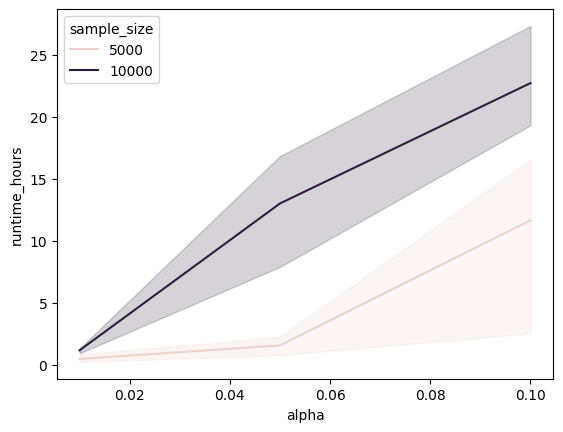

In [ ]:

sns.lineplot(
    data=df[df.algorithm=="FCI"],
    x="alpha",
    y="runtime_hours",
    hue="sample_size"
)

<Axes: xlabel='alpha', ylabel='memory'>

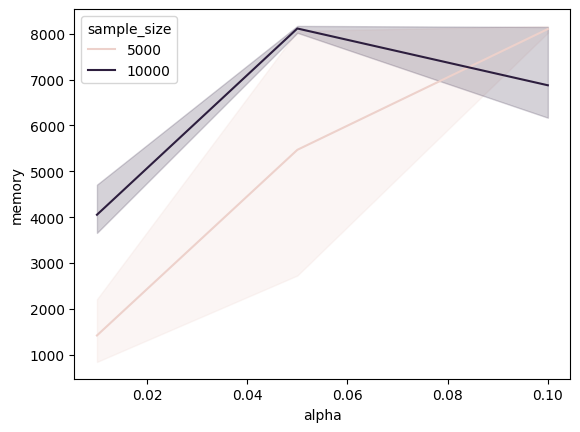

In [5]:
sns.lineplot(
    data=df[df.algorithm=="FCI"],
    x="alpha",
    y="memory",hue="sample_size"
)

<Axes: xlabel='alpha', ylabel='total_edges'>

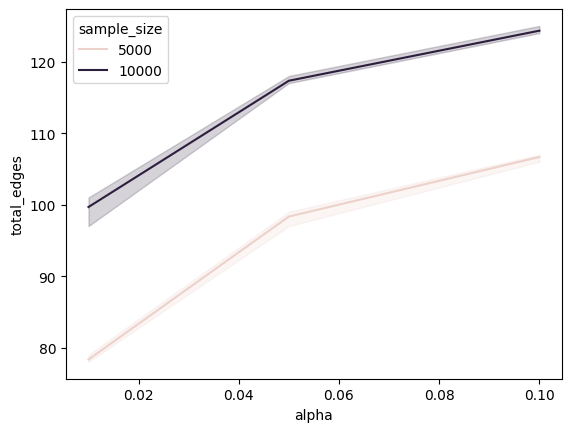

In [6]:
sns.lineplot(
    data=df[df.algorithm=="FCI"],
    x="alpha",
    y="total_edges",
    hue="sample_size"
)